# Threshold Tuning

Classification models usually predict probabilities instead of direct class labels.

By default, a threshold of **0.5** is used:
- If probability > 0.5 → class = 1  
- If probability ≤ 0.5 → class = 0  

## What is Threshold Tuning?

**Threshold tuning** means changing this cutoff value to improve model performance based on the problem requirement.

Instead of always using 0.5, we choose a threshold that better fits the business goal.

## Why Threshold Matters

Changing the threshold affects:
- Precision
- Recall
- False Positives
- False Negatives

So, it directly controls model behavior.

## Example Use Cases

### Fraud Detection
- Goal: Catch all fraud cases
- Strategy: **Lower threshold**
- Result: More fraud detected (higher recall), but more false alarms

### Medical Diagnosis
- Goal: Avoid missing sick patients
- Strategy: **Lower threshold**
- Result: Fewer false negatives (higher recall is important)

### Spam Detection
- Goal: Avoid marking real emails as spam
- Strategy: **Higher threshold**
- Result: Higher precision, fewer false positives

## Key Idea

- Lower threshold → more positive predictions  
- Higher threshold → stricter predictions  

## Conclusion

Threshold tuning helps balance:
- Precision vs Recall  
based on real-world business needs, not just model accuracy.

### Import libraries

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset (Binary Classification)
***Here, the digits dataset from scikit-learn is used***

We convert this into a binary problem:
- Class 1 → digit = 0  
- Class 0 → digit ≠ 0  

In [2]:
digits = load_digits()

X = digits.data
y = (digits.target == 0).astype(int)  # binary classification

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Model

In [3]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Get Prediction Probabilities

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]

### Try Different Thresholds
We check how precision and recall change with threshold.

In [5]:
thresholds = np.arange(0.1, 0.9, 0.1)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))

for i, t in enumerate(thresholds):
    print(f"Threshold: {t:.1f} | Precision: {precisions[i]:.2f} | Recall: {recalls[i]:.2f}")

Threshold: 0.1 | Precision: 0.97 | Recall: 1.00
Threshold: 0.2 | Precision: 1.00 | Recall: 1.00
Threshold: 0.3 | Precision: 1.00 | Recall: 1.00
Threshold: 0.4 | Precision: 1.00 | Recall: 1.00
Threshold: 0.5 | Precision: 1.00 | Recall: 0.97
Threshold: 0.6 | Precision: 1.00 | Recall: 0.94
Threshold: 0.7 | Precision: 1.00 | Recall: 0.94
Threshold: 0.8 | Precision: 1.00 | Recall: 0.94


### Visualize Threshold Effect 

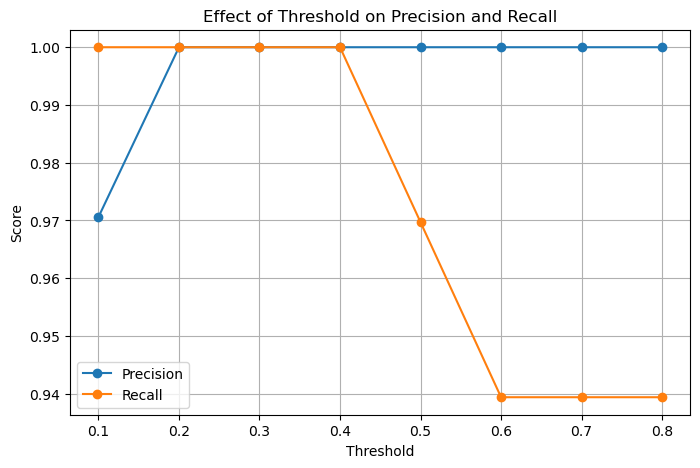

In [6]:
plt.figure(figsize=(8,5))

plt.plot(thresholds, precisions, marker='o', label="Precision")
plt.plot(thresholds, recalls, marker='o', label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Effect of Threshold on Precision and Recall")
plt.legend()
plt.grid()
plt.show()

### Key Observation

- Lower threshold → higher recall, lower precision  
- Higher threshold → higher precision, lower recall  


### Conclusion

Threshold tuning allows us to control model behavior based on real-world needs:
- Fraud detection → lower threshold  
- Medical diagnosis → lower threshold  
- Spam filtering → higher threshold  